In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Datos de Clientes Colombianos
# Score (300-950) Ingresos (1-10 SMMLV)

data = {
    'score': [400, 850, 320, 700, 550],
    'ingresos': [1.5, 8.0, 1.0, 4.0, 2.0],
    'pago': [0, 1, 0, 1, 0]}
df = pd.DataFrame(data)
df

,score,ingresos,pago
0,400,1.5,0
1,850,8.0,1
2,320,1.0,0
3,700,4.0,1
4,550,2.0,0


In [ ]:
x = df[['score', 'ingresos']]
y = df['pago']
clf = LogisticRegression()
clf.fit(x, y)

LogisticRegression()

In [ ]:
# Paso 4: Obtener probabilidades
print(clf.predict_proba([[600, 3.0]]))
print(clf.predict_proba([[850, 8.0]]))

[[0.92014797 0.07985203]]
[[2.76834333e-10 1.00000000e+00]]


In [18]:
# Configurar semilla para reproducibilidad
np.random.seed(42)
n = 2000

# 1. Generar variables independientes
score = np.random.randint(300, 950, n)
ingresos = np.random.uniform(1, 15, n)
monto = np.random.uniform(5, 100, n)
edad = np.random.randint(18, 70, n)
# La variable 'estrato' es comentada para hacer el punto 3 de la guia.
# Baja el 'accuracy' del modelo si se elimina esta var?
#estrato = np.random.choice([1, 2, 3, 4, 5, 6], n, p=[0.2, 0.3, 0.3, 0.1, 0.05, 0.05])
nivel_edu = np.random.choice(['Bachiller', 'Profesional', 'Posgrado'], n, p=[0.5, 0.4, 0.1])

# 2. Formula oculta de Z (Pesos simulados del comportamiento real)
# A mayor edad, ingresos y score, mayor Z. A mayor monto, menor Z

z = -8.0 + (0.01 * score) + (0.3 * ingresos) - (0.05 * monto) + (0.02 * edad)

# Agregamos un bonus al Z si el estrato es mayor a 3 (Simulando sesgo de datos)
#z = np.where(estrato > 3, z + 1.5, z)

# 3. Aplicar Sigmoide para obtener la probabilidad real
prob_real = 1 / (1 + np.exp(-z))
pago = np.random.binomial(1, prob_real) # 1 o 0 basado en la probabilidad

# 4. Crear DataFrame
df = pd.DataFrame({
    'Score': score, 'Ingresos_SMMLV': ingresos, 'Monto_Millones': monto,
    'Edad': edad, 'Nivel_Educativo': nivel_edu, 'Pago': pago
})
print(df.head())

   Score  Ingresos_SMMLV  Monto_Millones  Edad Nivel_Educativo  Pago
0    402       14.936727       37.076684    24        Posgrado     1
1    735        7.248933       98.909557    55       Bachiller     0
2    570        5.669974        7.397548    38       Bachiller     0
3    406        9.126650       29.001373    25     Profesional     0
4    371        2.242744       54.407036    68       Bachiller     0


In [19]:
# Paso 2: Ingenieria de Carateristicas (Niveles  Catogoricos)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Convertir variable categorica "Nivel_Educativo" en columnas Dummies (0 y 1)
df_procesado = pd.get_dummies(df,  columns=['Nivel_Educativo'], drop_first=True)

# Separar X (predictoras) y y (objetivo)
x = df_procesado.drop('Pago', axis=1)
y = df_procesado['Pago']

# 2. Division Train/Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Escalamiento de caracteristicas continuas
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar filtracion de datos
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Datos listos para la IA. Forma de x_train: ', x_train_scaled.shape)

Datos listos para la IA. Forma de x_train:  (1600, 6)


In [20]:
# 2.3 Paso 3: Entrenamiento y Extraccion de Pesos

from sklearn.linear_model import LogisticRegression

# Inicializar y entrenar
modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_train_scaled, y_train)

# Mostrar los coeficientes (Pesos Beta)
coeficientes = pd.DataFrame({
    'Variable': x.columns,
    'Peso (Beta)': modelo.coef_[0]
}).sort_values(by='Peso (Beta)', ascending=False)

print(coeficientes)

                      Variable  Peso (Beta)
0                        Score     1.785238
1               Ingresos_SMMLV     1.308614
3                         Edad     0.274641
5  Nivel_Educativo_Profesional     0.063954
4     Nivel_Educativo_Posgrado     0.052934
2               Monto_Millones    -1.295277


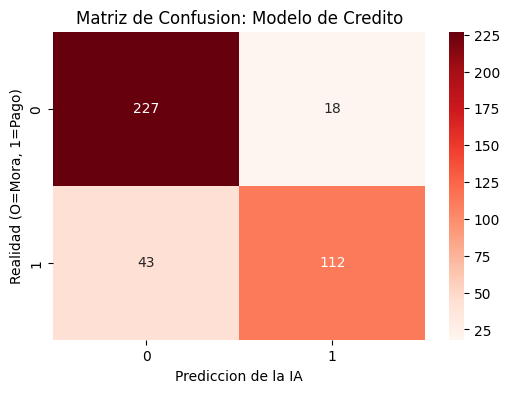


Reporte de Clasificacion:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       245
           1       0.86      0.72      0.79       155

    accuracy                           0.85       400
   macro avg       0.85      0.82      0.83       400
weighted avg       0.85      0.85      0.84       400



In [21]:
# Paso 4: Evaluacion de Riesgo

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = modelo.predict(x_test_scaled)

# Generar Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusion: Modelo de Credito')
plt.ylabel('Realidad (O=Mora, 1=Pago)')
plt.xlabel('Prediccion de la IA')
plt.show()

print("\nReporte de Clasificacion:")
print(classification_report(y_test, y_pred))

**1. Análisis de Coeficientes:** Según el DataFrame coeficientes impreso en el Paso 3, ¿Cuál variable penaliza más la solicitud del crédito (coeficiente negativo más alto)? ¿Tiene sentido financiero?

La variable que mas penaliza la solicitud de crédito es “Monto_Millones” con un peso de -1.32.
Esto tiene sentido financieramente porque un monto de credito demasiado alto (por encima de los ingresos del cliente) puede afectar su capacidad de pago.


**2. Predicción Personalizada:** Crea un cliente nuevo con tus propios datos (inventa el Score y el Monto). Recuerda aplicar el `scaler.transform()` a tu cliente antes de usar `modelo.predict_proba()`. ¿Cuál es tu probabilidad de aprobación?

In [ ]:
# 1. Datos del nuevo cliente
nuevo_cliente_data = {
    'Score': [750],
    'Ingresos_SMMLV': [6.0],
    'Monto_Millones': [30.0],
    'Edad': [45],
    'Estrato': [4],
    'Nivel_Educativo': ['Profesional']
}
nuevo_cliente_df = pd.DataFrame(nuevo_cliente_data)

# 2. Aplicar One-Hot Encoding (mismo que df_procesado)
nuevo_cliente_procesado = pd.get_dummies(nuevo_cliente_df, columns=['Nivel_Educativo'], drop_first=True)

# 3. Asegurarse de que las columnas coincidan con las de x_train
# Obtener todas las columnas presentes en x (usado para x_train)
columnas_x = x.columns

# Añadir columnas faltantes al nuevo_cliente_procesado y rellenar con 0
for col in columnas_x:
    if col not in nuevo_cliente_procesado.columns:
        nuevo_cliente_procesado[col] = 0

# Reordenar las columnas para que coincidan con x_train
nuevo_cliente_final = nuevo_cliente_procesado[columnas_x]

# 4. Escalar las características numéricas (usando el scaler previamente ajustado)
nuevo_cliente_scaled = scaler.transform(nuevo_cliente_final)

# 5. Predecir la probabilidad de pago
probabilidad_pago = modelo.predict_proba(nuevo_cliente_scaled)

print(f"Datos del nuevo cliente:\n{nuevo_cliente_df}")
print(f"\nProbabilidad de NO pago (Clase 0): {probabilidad_pago[0][0]:.4f}")
print(f"Probabilidad de SÍ pago (Clase 1): {probabilidad_pago[0][1]:.4f}")

if probabilidad_pago[0][1] > 0.5:
    print("\nEl modelo predice que el cliente SÍ pagará.")
else:
    print("\nEl modelo predice que el cliente NO pagará (tendrá mora).")

Datos del nuevo cliente:
   Score  Ingresos_SMMLV  Monto_Millones  Edad  Estrato Nivel_Educativo
0    750             6.0            30.0    45        4     Profesional

Probabilidad de NO pago (Clase 0): 0.1868
Probabilidad de SÍ pago (Clase 1): 0.8132

El modelo predice que el cliente SÍ pagará.


**3. Ética en IA:** Vuelve al Paso 1 y elimina la variable "Estrato" de la matriz X.
Vuelve a entrenar.

¿Baja drásticamente el "accuracy” del modelo? Si no baja mucho, ¿Deberı́a el banco eliminar esta variable por razones éticas?

Luego de eliminar la var 'estrato' el 'accuracy' del modelo no varia mucho. Cambia de 84 a 85. Lo cual quiere decir que no tiene un impacto significato en la prediccion de la respuesta de salida del modelo